
---

# 🔢 ***`Logistic Regression in Machine Learning for Data Science`*** 🚀  

## ✅ **What is Logistic Regression?**  

📌 **Logistic Regression** is a **classification algorithm** used to predict the **probability of a binary outcome** (e.g., Yes/No, 0/1, Spam/Not Spam).  

✔ **Used for binary classification problems** (e.g., fraud detection, spam filtering, disease diagnosis).  
✔ **Outputs probabilities** (values between **0 and 1**).  
✔ **Uses a sigmoid function** to map predictions into probabilities.  

---

## 🎯 **1. Why Use Logistic Regression Instead of Linear Regression?**  

📌 **Linear Regression is not suitable for classification because:**  
- It **does not constrain outputs between 0 and 1** (which is needed for probabilities).  
- It **does not model the S-shaped decision boundary**.  

📌 **Logistic Regression fixes this by applying a sigmoid function** to transform the linear model output into a probability.  

---

## 📏 **2. Mathematical Formulation of Logistic Regression**  

### 🔹 **Sigmoid Function (Logistic Function)**  

$
\sigma(z) = \frac{1}{1 + e^{-z}}
$

Where:  
- $ z = \theta_0 + \theta_1 X_1 + \theta_2 X_2 + ... + \theta_n X_n $ (linear combination of input features).  
- The output **$ \sigma(z) $** is a probability between **0 and 1**.  

### 🔹 **Logistic Regression Decision Rule**  

$
P(Y = 1 | X) = \frac{1}{1 + e^{-(\theta_0 + \theta_1 X_1 + ... + \theta_n X_n)}}
$

- If **$ P(Y=1) > 0.5 $** → Predict **Class 1**  
- If **$ P(Y=1) \leq 0.5 $** → Predict **Class 0**  

---

## 📉 **3. Cost Function for Logistic Regression**  

📌 **Instead of Mean Squared Error (MSE), we use Log Loss (Cross-Entropy Loss) in Logistic Regression:**  

$
J(\theta) = -\frac{1}{n} \sum_{i=1}^{n} \left[ Y_i \log(\hat{Y}_i) + (1 - Y_i) \log(1 - \hat{Y}_i) \right]
$

Where:  
- $ Y_i $ is the actual class (0 or 1).  
- $ \hat{Y}_i $ is the predicted probability.  
- The function **penalizes incorrect predictions heavily**.  

✔ **Minimizing log loss leads to better probability estimates**.  

---

## 🏹 **4. Implementing Logistic Regression in Python**  

### **📁 Dataset: Predicting if a Person Has Diabetes**  

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load Dataset
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv", header=None)

# Assign Column Names
df.columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome']

# Splitting Features & Target
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizing Features (Logistic Regression performs better with scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression Model
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

# Predictions
y_pred = log_reg.predict(X_test_scaled)

# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)


Accuracy: 0.7532467532467533

Confusion Matrix:
 [[79 20]
 [18 37]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154




📊 **Observations:**  
✔ **Accuracy Score** → Measures overall correctness.  
✔ **Confusion Matrix** → Shows **True Positives, False Positives, True Negatives, False Negatives**.  
✔ **Classification Report** → Includes **Precision, Recall, F1-score**.  

---

## 📊 **5. Evaluating Logistic Regression Performance**  

### 🔹 **Confusion Matrix & Performance Metrics**  

| **Metric** | **Formula** | **Interpretation** |
|------------|------------|---------------------|
| **Accuracy** | $ \frac{TP + TN}{TP + TN + FP + FN} $ | Overall correctness of the model |
| **Precision** | $ \frac{TP}{TP + FP} $ | How many predicted positives are actually positive |
| **Recall (Sensitivity)** | $ \frac{TP}{TP + FN} $ | How many actual positives were correctly predicted |
| **F1 Score** | $ 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} $ | Balance between Precision & Recall |

✔ **Use F1 Score when dealing with imbalanced classes.**  
✔ **Use ROC Curve & AUC Score for probability-based evaluation.**  

---

## 📈 **6. Visualizing Decision Boundary**  

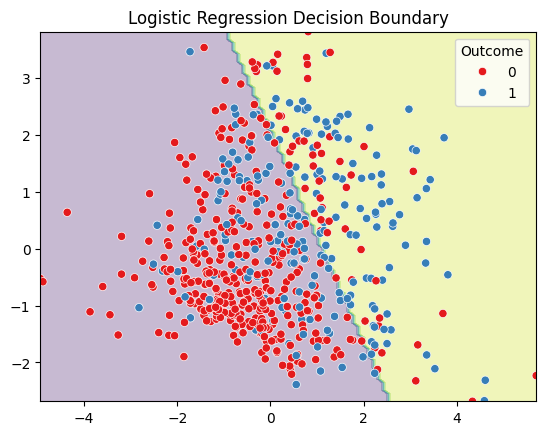

In [3]:
import seaborn as sns
from sklearn.decomposition import PCA

# Reduce Features to 2D using PCA for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Retrain Logistic Regression on PCA-reduced Data
log_reg_pca = LogisticRegression()
log_reg_pca.fit(X_train_pca, y_train)

# Decision Boundary Plot
xx, yy = np.meshgrid(np.linspace(X_train_pca[:, 0].min(), X_train_pca[:, 0].max(), 100),
                     np.linspace(X_train_pca[:, 1].min(), X_train_pca[:, 1].max(), 100))
Z = log_reg_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train, palette='Set1')
plt.title("Logistic Regression Decision Boundary")
plt.show()

📌 **Observations:**  

✔ **Blue & Red regions show decision boundary** for classification.  
✔ **Logistic Regression creates a linear decision boundary.**  

---

## 🔍 **7. Types of Logistic Regression**  

| **Type** | **Use Case** |
|------------|-------------|
| **Binary Logistic Regression** | Classifies into two categories (e.g., Spam/Not Spam, Default/No Default) |
| **Multinomial Logistic Regression** | Classifies into more than two categories (e.g., Dog, Cat, Bird) |
| **Ordinal Logistic Regression** | Ordered categories (e.g., Low, Medium, High risk) |

📌 **Use `LogisticRegression(multi_class='multinomial', solver='lbfgs')` for multi-class problems.**  

---

## 🏆 **8. Key Takeaways**  

✔ **Logistic Regression is a classification algorithm used for binary/multi-class classification.**  
✔ **Uses the sigmoid function to output probabilities between 0 and 1.**  
✔ **Log-Loss (Cross-Entropy) is the cost function.**  
✔ **Works best with standardized data.**  
✔ **Evaluated using accuracy, precision, recall, and F1-score.**  
✔ **Creates a linear decision boundary.**  

💡 **Pro Tip:** If the dataset has **non-linear relationships**, use **Polynomial Features, Decision Trees, or Neural Networks** for better results.

---

## **`Further Practice`**

In [17]:
# import libraries
import os
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, 
    classification_report,
    confusion_matrix,
)
from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder,
    MinMaxScaler,
)

import warnings
warnings.filterwarnings("ignore")

In [8]:
# load the dataset
df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [9]:
# pre-process the data

# 1. Remove the `deck` column
df.drop('deck',axis=1,inplace=True)

# 2. Impute missing Values in age,fare,embarked,embark_town
df['age'].fillna(df['age'].median(),inplace=True)
df['fare'].fillna(df['fare'].median(),inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0],inplace=True)
df['embark_town'].fillna(df['embark_town'].mode()[0],inplace=True)

# 3. Encode the Categorical Variables using for loop
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype == 'category':
        df[col] = le.fit_transform(df[col])

# view the preprocessed data
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,2,1,True,2,0,False
1,1,1,0,38.0,1,0,71.2833,0,0,2,False,0,1,False
2,1,3,0,26.0,0,0,7.9250,2,2,2,False,2,1,True
3,1,1,0,35.0,1,0,53.1000,2,0,2,False,2,1,False
4,0,3,1,35.0,0,0,8.0500,2,2,1,True,2,0,True


In [10]:
# spliting data into deoendent and independent variables
X = df.drop('survived',axis=1)
y = df['survived']

In [11]:
# train test split the data
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
)

In [12]:
# initialize the model
model = LogisticRegression()

# fit the model on training data
model.fit(X_train, y_train)

# predict with model
y_pred = model.predict(X_test)

# evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

# detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 1.00

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       110
           1       1.00      1.00      1.00        69

    accuracy                           1.00       179
   macro avg       1.00      1.00      1.00       179
weighted avg       1.00      1.00      1.00       179



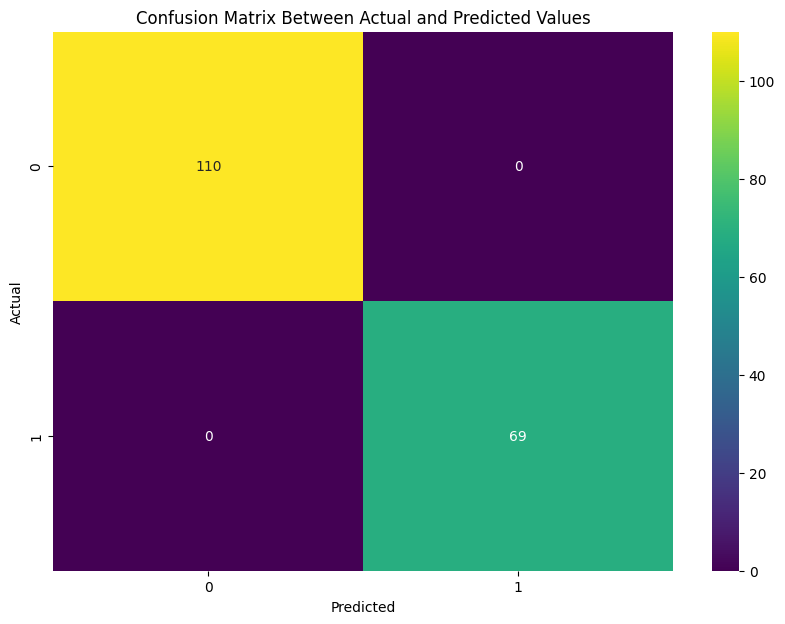

In [14]:
# plot the confusion matrix
plt.figure(figsize=(10,7))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d',cmap='viridis')
plt.title("Confusion Matrix Between Actual and Predicted Values")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# save the model
pickle.dump(model,open("./practice_models/logistic_regression_model.pkl","wb"))

---